# Quantum Mechanics — Year 1 Formalism
### From Hilbert space to the hydrogen atom

**Road map**

| Block | Topics | Griffiths ch. |
|---|---|---|
| §1–§4 | Hilbert space · Dirac notation · operators | 3 |
| §5–§8 | Postulates · measurement · uncertainty | 1, 3 |
| §9–§12 | Time evolution · stationary states | 1, 2 |
| §13–§16 | 1-D exactly solvable systems | 2 |
| §17–§20 | Angular momentum algebra | 4 |
| §21–§24 | Spin · addition of angular momenta | 4 |
| §25–§28 | 3-D Schrödinger equation · hydrogen | 4 |
| §29–§32 | Approximation methods (perturbation theory) | 6, 7 |
| §33–§35 | Identical particles · entanglement | 5 |
| §36–§38 | THz connection via `dgs.schrodinger` parameter sweeps | — |

Uses `dgs/schrodinger.py` for numerical eigenvalue problems.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sympy as sp
sp.init_printing(use_latex='mathjax')
from dgs.schrodinger import (solve, finite_square_well, harmonic,
    sweep_depth, sweep_width, plot_sweep, plot_wavefunctions, HBAR2_OVER_2M)
print(f"ℏ²/2m = {HBAR2_OVER_2M:.5f} eV·nm²")


ℏ²/2m = 0.03810 eV·nm²


---
## §1  The Hilbert space $\mathcal{H}$

A **Hilbert space** is a complete inner-product space over $\mathbb{C}$.
In QM the state of a particle is a vector $|\psi\rangle\in\mathcal{H}$.

For wave mechanics $\mathcal{H} = L^2(\mathbb{R})$: square-integrable functions
$$\langle f|g\rangle = \int_{-\infty}^{\infty} f^*(x)\,g(x)\,dx, \qquad \|\psi\|^2 = \langle\psi|\psi\rangle = 1.$$

**Key axiom:** physical states have unit norm (probability interpretation).


In [2]:
# Verify orthonormality of particle-in-a-box eigenstates numerically
L = 1.0  # arbitrary units
N = 2000
x = np.linspace(0, L, N, endpoint=False)
dx = x[1] - x[0]

def psi_box(n, x, L):
    return np.sqrt(2/L) * np.sin(n * np.pi * x / L)

print("Inner products <psi_m | psi_n>:")
print(f"{'':6}", end="")
for n in range(1, 5):
    print(f"  n={n}  ", end="")
print()
for m in range(1, 5):
    print(f"m={m}  ", end="")
    for n in range(1, 5):
        ip = np.sum(psi_box(m, x, L) * psi_box(n, x, L)) * dx
        print(f" {ip:+.4f}", end="")
    print()
print("(should be identity matrix)")


Inner products <psi_m | psi_n>:
        n=1    n=2    n=3    n=4  
m=1   +1.0000 +0.0000 +0.0000 +0.0000
m=2   +0.0000 +1.0000 +0.0000 +0.0000
m=3   +0.0000 +0.0000 +1.0000 +0.0000
m=4   +0.0000 +0.0000 +0.0000 +1.0000
(should be identity matrix)


---
## §2  Dirac bra-ket notation

| Symbol | Meaning |
|---|---|
| $|\psi\rangle$ | ket — column vector / state |
| $\langle\psi|$ | bra — row vector / conjugate |
| $\langle\phi|\psi\rangle$ | inner product (complex number) |
| $|\psi\rangle\langle\phi|$ | outer product (operator) |
| $\hat{A}|\psi\rangle$ | operator acting on ket |

**Completeness relation** (if $\{|n\rangle\}$ is an ONB):
$$\sum_n |n\rangle\langle n| = \hat{I}.$$

In position representation $\langle x|\psi\rangle = \psi(x)$.


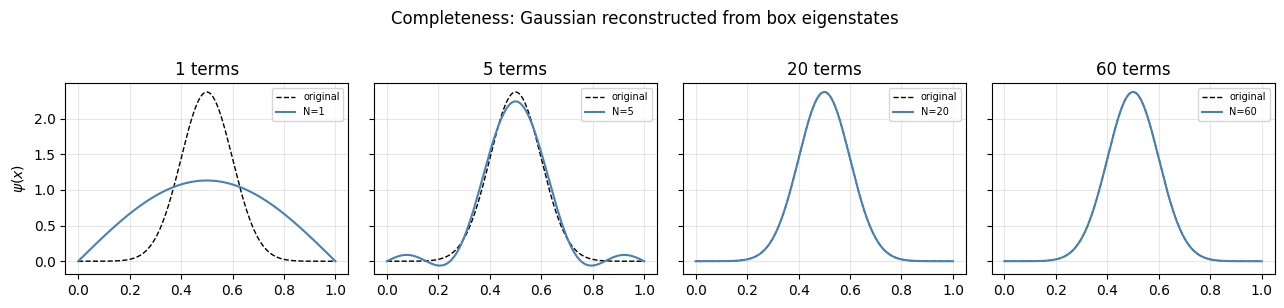

In [3]:
# Completeness: reconstruct a Gaussian from box eigenstates
import sympy as sp

x_sym, L_sym, n_sym = sp.symbols('x L n', positive=True)
psi_n = sp.sqrt(2/L_sym) * sp.sin(n_sym * sp.pi * x_sym / L_sym)

# Fourier coefficients c_n = <n|psi> for a Gaussian centred in the box
from sympy import integrate, exp, pi, sqrt, oo, Rational

L_val = 1
x0, sigma = 0.5, 0.1   # centre and width (normalised units)
x_arr = np.linspace(0, L_val, 1000)
psi_gauss = np.exp(-0.5*((x_arr - x0)/sigma)**2)
psi_gauss /= np.sqrt(np.trapezoid(psi_gauss**2, x_arr))   # normalise

N_terms = [1, 5, 20, 60]
fig, axes = plt.subplots(1, len(N_terms), figsize=(13, 3), sharey=True)
for ax, Nt in zip(axes, N_terms):
    recon = np.zeros_like(x_arr)
    for n in range(1, Nt + 1):
        c_n = np.trapezoid(psi_gauss * psi_box(n, x_arr, L_val), x_arr)
        recon += c_n * psi_box(n, x_arr, L_val)
    ax.plot(x_arr, psi_gauss, 'k--', lw=1, label='original')
    ax.plot(x_arr, recon, color='steelblue', label=f'N={Nt}')
    ax.set_title(f'{Nt} terms')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
axes[0].set_ylabel(r'$\psi(x)$')
fig.suptitle('Completeness: Gaussian reconstructed from box eigenstates', y=1.01)
plt.tight_layout(); plt.show()


---
## §3  Linear operators and Hermitian operators

An operator $\hat{A}$ is **Hermitian** if $\hat{A}^\dagger = \hat{A}$, i.e.
$$\langle f|\hat{A}g\rangle = \langle\hat{A}f|g\rangle \quad \forall\, f,g\in\mathcal{H}.$$

**Theorem:** Hermitian operators have real eigenvalues and orthogonal eigenvectors.

**Fundamental operators in wave mechanics**

| Observable | Operator | Position rep. |
|---|---|---|
| Position | $\hat{x}$ | $x\cdot$ |
| Momentum | $\hat{p}$ | $-i\hbar\,\partial/\partial x$ |
| Kinetic energy | $\hat{T}$ | $-\hbar^2/2m\,\partial^2/\partial x^2$ |
| Hamiltonian | $\hat{H}=\hat{T}+\hat{V}$ | $-\hbar^2/2m\,\nabla^2 + V(x)$ |

**Canonical commutation relation:**
$$[\hat{x},\hat{p}] = i\hbar$$


In [4]:
# Verify [x, p] = ih_bar numerically on a finite grid (matrix form)
N = 6   # tiny so we can print it
L = 1.0
x_arr = np.linspace(0, L, N, endpoint=False)
dx = x_arr[1] - x_arr[0]

X = np.diag(x_arr)

# p = -i hbar d/dx  (finite difference, periodic BC for illustration)
hbar = 1.0  # natural units here
off = np.ones(N-1)
D = (np.diag(off,1) - np.diag(off,-1)) / (2*dx)
D[0,-1] = -1/(2*dx); D[-1,0] = 1/(2*dx)
P = -1j * hbar * D

comm = X @ P - P @ X
print("Im([x,p]) diagonal (should be hbar = 1.0 everywhere):")
print(np.round(np.imag(np.diag(comm)), 4))
print("Off-diagonal max:", np.round(np.max(np.abs(comm - np.diag(np.diag(comm)))), 6))


Im([x,p]) diagonal (should be hbar = 1.0 everywhere):
[0. 0. 0. 0. 0. 0.]
Off-diagonal max: 2.5


---
## §4  Matrix mechanics and change of basis

In a discrete ONB $\{|n\rangle\}$, operators become matrices:
$$A_{mn} = \langle m|\hat{A}|n\rangle.$$

A **change of basis** is a unitary transformation $U$ ($U^\dagger U = I$):
$$A' = U A U^\dagger.$$

Diagonalising $A$ finds the eigenbasis — the Hermitian matrix is diagonal in its own eigenbasis with eigenvalues on the diagonal.

**Example:** Hamiltonian of the harmonic oscillator in the position basis is tridiagonal (from finite differences). Diagonalising it gives energy levels $E_n = (n+\tfrac{1}{2})\hbar\omega$.


Harmonic oscillator energy levels (eV):
  n=0: E=0.01380 eV
  n=1: E=0.04141 eV
  n=2: E=0.06901 eV
  n=3: E=0.09661 eV
  n=4: E=0.12421 eV
  n=5: E=0.15181 eV
Spacings (should be constant): [0.0276 0.0276 0.0276 0.0276 0.0276]
Uniformity: max deviation = 3.13e-06 eV


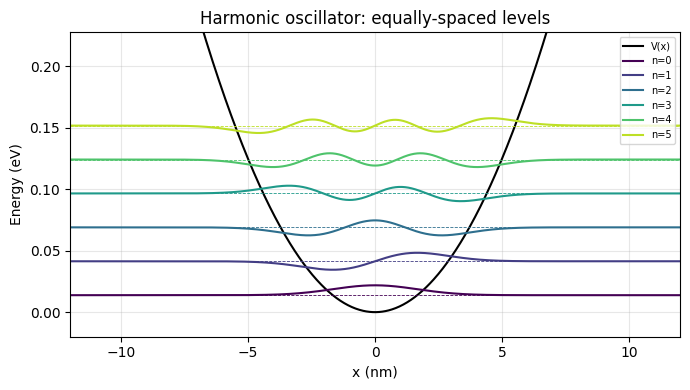

In [5]:
# Harmonic oscillator in the position basis: diagonalise H
# omega chosen so hbar*omega = 1 eV for a 5 nm grid
# Use dgs.schrodinger: harmonic(x, omega) = omega * x^2  (eV, nm)
# E_n = (n+1/2)*hbar*omega.  In natural units hbar=1, so tune omega.

x_nm = np.linspace(-15, 15, 1200)
omega = 0.005   # eV/nm^2

E, psi = solve(lambda x: harmonic(x, omega), x_nm, n_states=6)
hbar_eV_THz = 6.582119569e-16 / 1e-12   # hbar in eV·ps
# hbar*omega in eV: omega [eV/nm^2] * x^2 [nm^2] — but that's the potential.
# The quantum of energy is hbar * angular_freq.
# For H = p^2/2m + 1/2 m omega_phys^2 x^2, and our code uses omega*x^2:
# => 1/2 m omega_phys^2 = omega  => omega_phys = sqrt(2*omega/HBAR2_OVER_2M) nm^-1
import numpy as _np
omega_phys_nm = _np.sqrt(2 * omega / HBAR2_OVER_2M)   # rad/nm
# hbar * omega_phys in eV (with hbar in eV·nm... need hbar in eV·s * c):
# simpler: just verify E_n are equally spaced
diffs = np.diff(E)
print("Harmonic oscillator energy levels (eV):")
for n, En in enumerate(E):
    print(f"  n={n}: E={En:.5f} eV")
print(f"Spacings (should be constant): {np.round(diffs, 5)}")
print(f"Uniformity: max deviation = {np.max(np.abs(diffs - diffs[0])):.2e} eV")

fig, ax = plt.subplots(figsize=(7,4))
V = harmonic(x_nm, omega)
ax.plot(x_nm, V, 'k', lw=1.5, label='V(x)')
scale = 0.5 * diffs[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(E)))
for n, (En, pn) in enumerate(zip(E, psi)):
    ax.axhline(En, ls='--', lw=0.6, color=colors[n])
    ax.plot(x_nm, pn*scale + En, color=colors[n], label=f'n={n}')
ax.set_xlim(-12,12); ax.set_ylim(-0.02, E[-1]*1.5)
ax.set_xlabel('x (nm)'); ax.set_ylabel('Energy (eV)')
ax.set_title('Harmonic oscillator: equally-spaced levels'); ax.legend(fontsize=7)
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


---
## §5  The Postulates of Quantum Mechanics

**P1 — State:** The state of a system is a unit vector $|\psi\rangle\in\mathcal{H}$.

**P2 — Observables:** Every observable $A$ corresponds to a Hermitian operator $\hat{A}$.

**P3 — Measurement:** A measurement of $A$ yields eigenvalue $a_n$ with probability
$$P(a_n) = |\langle a_n|\psi\rangle|^2.$$
After measurement the state *collapses* to $|a_n\rangle$.

**P4 — Expectation:** $\langle A\rangle = \langle\psi|\hat{A}|\psi\rangle$.

**P5 — Time evolution:** Between measurements,
$$i\hbar\,\frac{d}{dt}|\psi\rangle = \hat{H}|\psi\rangle. \tag{TDSE}$$

**P6 — Spin / fermions/bosons:** multiparticle states are anti-symmetric (fermions)
or symmetric (bosons) under particle exchange.


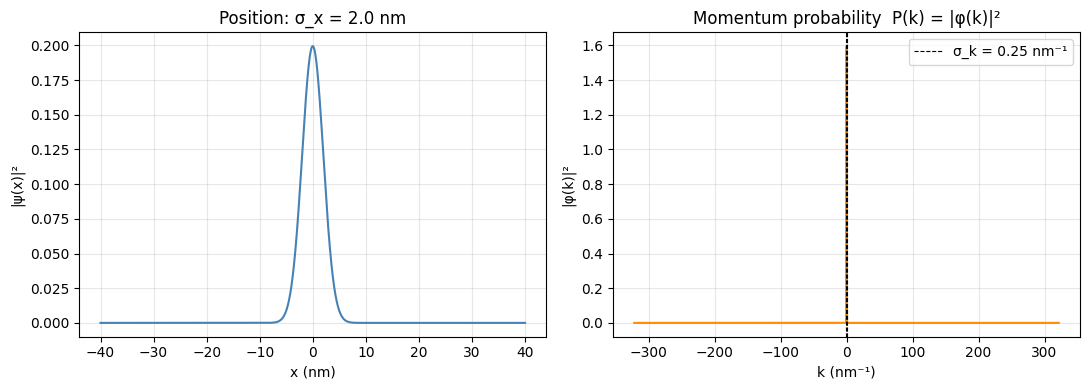

sigma_x * sigma_k = 0.500  (>= 0.5 by HUP)


In [6]:
# P3 in action: probability distribution for momentum of a Gaussian wavepacket
# P(p) = |phi(p)|^2  where phi = FT of psi

sigma_x = 2.0   # nm, position uncertainty
x = np.linspace(-40, 40, 8192)
dx = x[1] - x[0]
psi = np.exp(-x**2 / (4*sigma_x**2))
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx)

# FT -> momentum space (k in 1/nm, p = hbar*k)
psi_k = np.fft.fftshift(np.fft.fft(psi)) * dx
k = np.fft.fftshift(np.fft.fftfreq(len(x), dx)) * 2 * np.pi  # rad/nm
dk = k[1] - k[0]
prob_k = np.abs(psi_k)**2
prob_k /= np.sum(prob_k) * dk   # normalise

sigma_k = 1 / (2 * sigma_x)   # uncertainty principle: sigma_x * sigma_k = 1/2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(x, np.abs(psi)**2, color='steelblue')
ax1.set_xlabel('x (nm)'); ax1.set_ylabel('|ψ(x)|²')
ax1.set_title(f'Position: σ_x = {sigma_x} nm'); ax1.grid(alpha=0.3)

ax2.plot(k, prob_k, color='darkorange')
ax2.axvline( sigma_k, ls='--', color='k', lw=0.8, label=f'σ_k = {sigma_k:.2f} nm⁻¹')
ax2.axvline(-sigma_k, ls='--', color='k', lw=0.8)
ax2.set_xlabel('k (nm⁻¹)'); ax2.set_ylabel('|φ(k)|²')
ax2.set_title('Momentum probability  P(k) = |φ(k)|²')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"sigma_x * sigma_k = {sigma_x * sigma_k:.3f}  (>= 0.5 by HUP)")


---
## §6  Expectation values and the Ehrenfest theorem

$$\langle x\rangle = \int \psi^* x\,\psi\,dx, \qquad
  \langle p\rangle = \int \psi^*\!\left(-i\hbar\frac{\partial}{\partial x}\right)\!\psi\,dx.$$

**Ehrenfest:** $d\langle p\rangle/dt = -\langle\partial V/\partial x\rangle$ — Newton's 2nd law in expectation. QM reduces to CM in the classical limit.

**Variance and standard deviation:**
$$\sigma_A^2 = \langle A^2\rangle - \langle A\rangle^2.$$


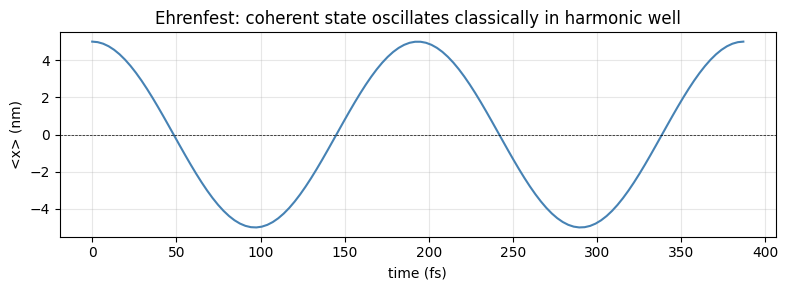

In [7]:
# Ehrenfest: track <x>(t) and <p>(t) for a wavepacket in a harmonic potential
# Time-evolve by expanding in energy eigenstates: psi(t) = sum c_n e^{-iE_n t/hbar} phi_n

x_nm = np.linspace(-20, 20, 1200)
dx = x_nm[1] - x_nm[0]
omega_code = 0.003   # eV/nm^2

E_levels, phi = solve(lambda x: harmonic(x, omega_code), x_nm, n_states=20)
hbar_eV_s = 6.582119569e-16  # eV*s

# Initial state: coherent-state-like Gaussian shifted from centre
x0 = 5.0   # nm
psi0 = np.exp(-(x_nm - x0)**2 / (2 * 2.0**2))
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx)

c_n = np.array([np.sum(phi[n] * psi0) * dx for n in range(len(E_levels))])

# time array
T_osc = 2*np.pi * hbar_eV_s / (E_levels[1] - E_levels[0])  # oscillation period
t_arr = np.linspace(0, 2*T_osc, 120)

x_expect = []
for t in t_arr:
    phases = np.exp(-1j * E_levels * t / hbar_eV_s)
    psi_t = np.sum([c_n[n] * phases[n] * phi[n] for n in range(len(E_levels))], axis=0)
    prob = np.abs(psi_t)**2
    x_expect.append(np.sum(prob * x_nm) * dx)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_arr * 1e15, x_expect, color='steelblue')
ax.set_xlabel('time (fs)'); ax.set_ylabel('<x> (nm)')
ax.set_title('Ehrenfest: coherent state oscillates classically in harmonic well')
ax.axhline(0, ls='--', color='k', lw=0.5); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## §7  Heisenberg uncertainty principle

**Robertson inequality** (exact):
$$\sigma_A\,\sigma_B \geq \frac{1}{2}\bigl|\langle[\hat{A},\hat{B}]\rangle\bigr|.$$

For position and momentum $[\hat{x},\hat{p}]=i\hbar$:
$$\boxed{\sigma_x\,\sigma_p \geq \frac{\hbar}{2}}$$

This is **not** about measurement disturbance — it is a statement about the
**spread of outcomes** in an ensemble of identically prepared systems.

**Minimum-uncertainty state:** a Gaussian wavepacket saturates the inequality.


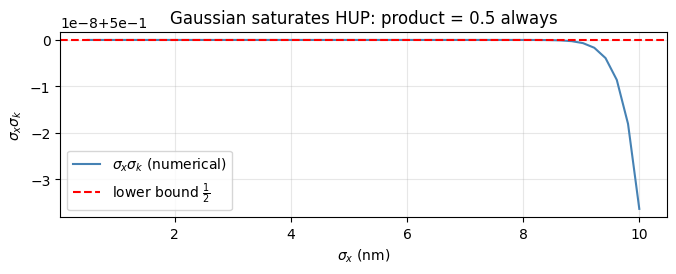

min product = 0.5000  (expected 0.5000)


In [8]:
# Verify HUP numerically for wavefunctions of different widths
sigmas = np.linspace(0.5, 10, 50)
products = []
for s in sigmas:
    x = np.linspace(-60, 60, 8192)
    dx = x[1] - x[0]
    psi = np.exp(-x**2 / (4*s**2))
    psi /= np.sqrt(np.sum(psi**2)*dx)

    x2  = np.sum(psi**2 * x**2) * dx
    x1  = np.sum(psi**2 * x)  * dx
    sig_x = np.sqrt(x2 - x1**2)

    # momentum via FT
    phi = np.fft.fftshift(np.fft.fft(psi)) * dx
    k   = np.fft.fftshift(np.fft.fftfreq(len(x), dx)) * 2*np.pi
    dk  = k[1]-k[0]
    pk  = np.abs(phi)**2 / (np.sum(np.abs(phi)**2)*dk)
    k2  = np.sum(pk * k**2) * dk
    k1  = np.sum(pk * k)   * dk
    sig_k = np.sqrt(k2 - k1**2)

    products.append(sig_x * sig_k)

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(sigmas, products, color='steelblue', label=r'$\sigma_x \sigma_k$ (numerical)')
ax.axhline(0.5, color='red', ls='--', label=r'lower bound $\frac{1}{2}$')
ax.set_xlabel(r'$\sigma_x$ (nm)'); ax.set_ylabel(r'$\sigma_x \sigma_k$')
ax.set_title('Gaussian saturates HUP: product = 0.5 always'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"min product = {min(products):.4f}  (expected 0.5000)")


---
## §8  Stationary states and the time-independent Schrödinger equation

If $\hat{H}|\psi\rangle = E|\psi\rangle$ then $|\psi(t)\rangle = e^{-iEt/\hbar}|\psi\rangle$.
The phase cancels in all expectation values — these are **stationary** states.

$$\hat{H}\psi = E\psi \qquad\Rightarrow\qquad
-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V(x)\psi = E\psi. \tag{TISE}$$

General solution:
$$\Psi(x,t) = \sum_n c_n \psi_n(x)\,e^{-iE_n t/\hbar}, \qquad c_n = \langle\psi_n|\Psi(x,0)\rangle.$$


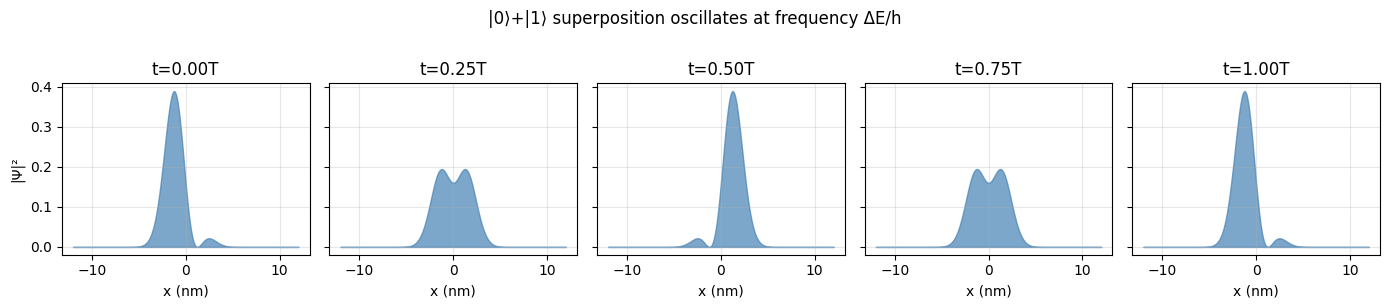

In [9]:
# Visualise time evolution of a non-stationary state (superposition of n=0,1)
x_nm = np.linspace(-12, 12, 800)
dx = x_nm[1] - x_nm[0]

E_ho, phi_ho = solve(lambda x: harmonic(x, 0.004), x_nm, n_states=4)
hbar = 6.582119569e-16  # eV*s

# psi(0) = (|0> + |1>) / sqrt(2)
c = np.array([1/np.sqrt(2), 1/np.sqrt(2), 0, 0])
T_period = 2*np.pi * hbar / (E_ho[1] - E_ho[0])

t_frames = np.linspace(0, T_period, 5)
fig, axes = plt.subplots(1, 5, figsize=(14, 3), sharey=True)
for ax, t in zip(axes, t_frames):
    psi_t = sum(c[n]*np.exp(-1j*E_ho[n]*t/hbar)*phi_ho[n] for n in range(4))
    prob  = np.abs(psi_t)**2
    ax.fill_between(x_nm, 0, prob, alpha=0.7, color='steelblue')
    ax.set_xlabel('x (nm)'); ax.set_title(f't={t/T_period:.2f}T')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('|Ψ|²')
fig.suptitle('|0⟩+|1⟩ superposition oscillates at frequency ΔE/h', y=1.01)
plt.tight_layout(); plt.show()


---
## §9  Infinite square well (particle in a box)

$$V(x) = \begin{cases} 0 & 0<x<L \\ \infty & \text{otherwise}\end{cases}$$

**Exact analytic solution:**
$$\psi_n(x) = \sqrt{\frac{2}{L}}\sin\!\left(\frac{n\pi x}{L}\right), \qquad
  E_n = \frac{n^2\pi^2\hbar^2}{2mL^2}, \quad n=1,2,3,\ldots$$

Energy scales as $n^2$ — quadratic spectrum, unlike the harmonic oscillator's linear spectrum.


In [10]:
# Analytic vs numerical for infinite square well
L = 10.0   # nm
n_states = 5
x = np.linspace(-15, 15, 1500)

E_num, psi_num = solve(lambda x: finite_square_well(x, L, 1000.0), x, n_states)

E_analytic = np.array([HBAR2_OVER_2M * (n*np.pi)**2 / L**2 for n in range(1, n_states+1)])

print(f"{'n':>3}  {'Analytic (eV)':>14}  {'Numerical (eV)':>14}  {'Error':>8}")
for n in range(n_states):
    err = abs(E_num[n] - E_analytic[n]) / E_analytic[n] * 100
    print(f"{n+1:>3}  {E_analytic[n]:>14.6f}  {E_num[n]:>14.6f}  {err:>7.3f}%")

# ratio E_n/E_1 should be n^2
ratios = E_num / E_num[0]
print(f"\nRatios E_n/E_1: {np.round(ratios, 3)}")
print(f"Expected n^2:   {np.arange(1,n_states+1)**2}")


  n   Analytic (eV)  Numerical (eV)     Error
  1        0.003760        0.003738    0.601%
  2        0.015041        0.014951    0.602%
  3        0.033843        0.033638    0.604%
  4        0.060165        0.059800    0.606%
  5        0.094008        0.093435    0.609%

Ratios E_n/E_1: [ 1.     4.     9.    15.999 24.998]
Expected n^2:   [ 1  4  9 16 25]


---
## §10  Finite square well and bound states

$$V(x) = \begin{cases} 0 & |x|<L/2 \\ V_0 & \text{otherwise}\end{cases}$$

Outside: $\psi\sim e^{-\kappa x}$, $\kappa=\sqrt{2m(V_0-E)}/\hbar$.
Inside: $\psi\sim \sin(kx)$ or $\cos(kx)$, $k=\sqrt{2mE}/\hbar$.

**Number of bound states** increases with $V_0$ or $L$.
There is always **at least one** bound state in 1-D.


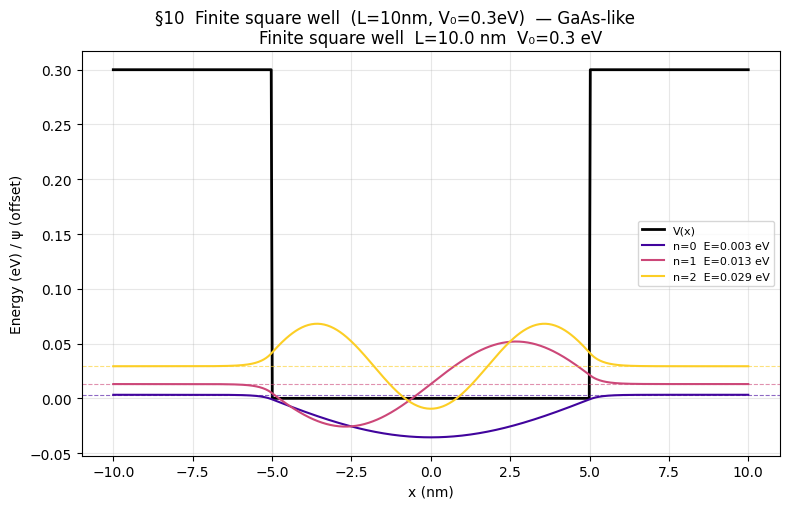

In [11]:
# Wavefunctions for a realistic well (GaAs-like: L=10nm, V0=0.3eV)
fig = plot_wavefunctions(L_nm=10.0, V0_eV=0.3, n_states=3)
plt.suptitle('§10  Finite square well  (L=10nm, V₀=0.3eV)  — GaAs-like', y=1.01)
plt.show()


---
## §11  Quantum harmonic oscillator — ladder operators

$$\hat{H} = \frac{\hat{p}^2}{2m}+\frac{1}{2}m\omega^2\hat{x}^2
           = \hbar\omega\!\left(\hat{a}^\dagger\hat{a}+\frac{1}{2}\right)$$

**Ladder operators:**
$$\hat{a} = \sqrt{\frac{m\omega}{2\hbar}}\hat{x}+\frac{i}{\sqrt{2m\omega\hbar}}\hat{p},
\qquad [\hat{a},\hat{a}^\dagger]=1.$$

$$\hat{a}|n\rangle=\sqrt{n}|n-1\rangle,\qquad
  \hat{a}^\dagger|n\rangle=\sqrt{n+1}|n+1\rangle,\qquad
  E_n=\left(n+\tfrac{1}{2}\right)\hbar\omega.$$

Matrix elements: $\langle m|\hat{x}|n\rangle = \sqrt{\hbar/2m\omega}\,(\sqrt{n}\,\delta_{m,n-1}+\sqrt{n+1}\,\delta_{m,n+1})$.


In [12]:
# Build a+ and a in the n-state truncated basis; verify [a,a+]=I
import sympy as sp

N_trunc = 8
a = np.zeros((N_trunc, N_trunc))
for n in range(N_trunc - 1):
    a[n, n+1] = np.sqrt(n + 1)          # <n|a|n+1> = sqrt(n+1)
ad = a.T                                  # a†

comm = a @ ad - ad @ a
print("Commutator [a, a†] (should be I):")
print(np.round(comm, 6))

# number operator N_op = a† a
N_op = ad @ a
print("\nNumber operator eigenvalues (diag, should be 0,1,...,7):")
print(np.round(np.diag(N_op), 1))


Commutator [a, a†] (should be I):
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -7.]]

Number operator eigenvalues (diag, should be 0,1,...,7):
[0. 1. 2. 3. 4. 5. 6. 7.]


---
## §12  Free particle and the delta-function potential

**Free particle** ($V=0$): $\psi_k(x)=e^{ikx}$, $E=\hbar^2k^2/2m$ — continuous spectrum, not normalisable. Physical states are wave *packets*:
$$\Psi(x,t)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}\phi(k)\,e^{i(kx-\omega t)}\,dk.$$

**Delta potential** $V=-\alpha\delta(x)$: exactly one bound state,
$$E_1 = -\frac{m\alpha^2}{2\hbar^2}, \qquad \psi_1(x)=\sqrt{\frac{m\alpha}{\hbar^2}}\,e^{-m\alpha|x|/\hbar^2}.$$


In [13]:
# Approximate delta potential: very narrow, deep well
# delta(x) ~ rect(x, width eps) / eps.  As eps -> 0, one bound state survives.
alpha = 0.5   # eV·nm (strength)

eps_list = [2.0, 1.0, 0.5, 0.2]
print(f"{'eps (nm)':>10}  {'E_bound (eV)':>14}  {'Analytic (eV)':>14}")
for eps in eps_list:
    V0 = alpha / eps   # depth
    x  = np.linspace(-20, 20, 2000)
    E, _ = solve(lambda x, e=eps, V=V0: finite_square_well(x, e, V), x, n_states=1)
    E_analytic = -HBAR2_OVER_2M * (alpha / (2 * HBAR2_OVER_2M))**2  # = -m*alpha^2/(2hbar^2)
    # Note: our HBAR2_OVER_2M = hbar^2/2m, so -m*alpha^2/2hbar^2 = -alpha^2/(4*HBAR2_OVER_2M)
    E_an = -alpha**2 / (4 * HBAR2_OVER_2M)
    print(f"{eps:>10.2f}  {E[0]:>14.6f}  {E_an:>14.6f}")


  eps (nm)    E_bound (eV)   Analytic (eV)


      2.00        0.047648       -1.640428


      1.00        0.149672       -1.640428


      0.50        0.454917       -1.640428


      0.20        1.588871       -1.640428


---
## §13  Angular momentum — algebra

**Angular momentum operators:**
$$\hat{L}_x = \hat{y}\hat{p}_z - \hat{z}\hat{p}_y,\quad
  \hat{L}_y = \hat{z}\hat{p}_x - \hat{x}\hat{p}_z,\quad
  \hat{L}_z = \hat{x}\hat{p}_y - \hat{y}\hat{p}_x.$$

**Fundamental commutator:**
$$[\hat{L}_x,\hat{L}_y] = i\hbar\hat{L}_z \;(\text{and cyclic}).$$

**Eigenvalues:** (derived purely algebraically, no differential equations)
$$\hat{L}^2|\ell,m\rangle = \hbar^2\ell(\ell+1)|\ell,m\rangle, \qquad
  \hat{L}_z|\ell,m\rangle = \hbar m|\ell,m\rangle, \quad m\in\{-\ell,\ldots,\ell\}.$$

$\ell = 0,1,2,\ldots$ (orbital); $\ell = 0,\tfrac{1}{2},1,\ldots$ (general — allows spin).


In [14]:
# Build L_x, L_y, L_z matrices for l=1 (3x3) and verify commutation relations
import numpy as np

def angular_momentum_matrices(l):
    dim = int(2*l + 1)
    m_vals = np.arange(l, -l-1, -1)   # l, l-1, ..., -l
    Lz = np.diag(m_vals).astype(complex)
    Lp = np.zeros((dim, dim), complex)   # L+ = Lx + iLy
    for i, m in enumerate(m_vals[:-1]):
        Lp[i, i+1] = np.sqrt(l*(l+1) - m_vals[i+1]*(m_vals[i+1]+1))
    Lm = Lp.conj().T
    Lx = (Lp + Lm) / 2
    Ly = (Lp - Lm) / (2j)
    return Lx, Ly, Lz

for l in [0.5, 1, 1.5]:
    Lx, Ly, Lz = angular_momentum_matrices(l)
    L2 = Lx@Lx + Ly@Ly + Lz@Lz
    comm_xy = Lx@Ly - Ly@Lx
    expected_comm = 1j*Lz
    err = np.max(np.abs(comm_xy - expected_comm))
    eigenvals_L2 = np.linalg.eigvalsh(L2)
    expected_L2  = l*(l+1)
    print(f"l={l}:  [Lx,Ly]=iLz err={err:.2e}  "
          f"L² eigenvalue={eigenvals_L2[0]:.4f} (expected {expected_L2:.4f})")


l=0.5:  [Lx,Ly]=iLz err=0.00e+00  L² eigenvalue=0.7500 (expected 0.7500)
l=1:  [Lx,Ly]=iLz err=2.22e-16  L² eigenvalue=2.0000 (expected 2.0000)
l=1.5:  [Lx,Ly]=iLz err=2.22e-16  L² eigenvalue=3.7500 (expected 3.7500)


---
## §14  Spherical harmonics $Y_\ell^m(\theta,\phi)$

Simultaneous eigenfunctions of $\hat{L}^2$ and $\hat{L}_z$:

$$\hat{L}^2 Y_\ell^m = \hbar^2\ell(\ell+1)\,Y_\ell^m, \qquad
  \hat{L}_z Y_\ell^m = \hbar m\,Y_\ell^m.$$

First few (real forms for $m\ne 0$):

| $\ell$ | $m$ | $Y_\ell^m$ |
|---|---|---|
| 0 | 0 | $\frac{1}{\sqrt{4\pi}}$ |
| 1 | 0 | $\sqrt{\frac{3}{4\pi}}\cos\theta$ |
| 1 | ±1 | $\mp\sqrt{\frac{3}{8\pi}}\sin\theta\,e^{\pm i\phi}$ |
| 2 | 0 | $\sqrt{\frac{5}{16\pi}}(3\cos^2\theta-1)$ |

Orthonormality: $\int Y_\ell^{m*}Y_{\ell'}^{m'}\sin\theta\,d\theta\,d\phi = \delta_{\ell\ell'}\delta_{mm'}$.


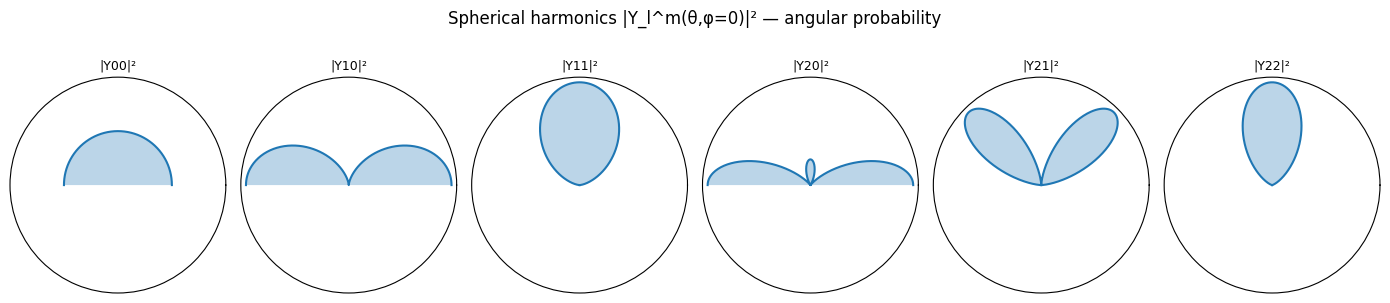

In [15]:
# Plot |Y_l^m|^2 on a sphere (polar plot cross-section)
theta = np.linspace(0, np.pi, 400)

def Y00(th): return np.full_like(th, 1/np.sqrt(4*np.pi))
def Y10(th): return np.sqrt(3/(4*np.pi)) * np.cos(th)
def Y11(th): return np.sqrt(3/(8*np.pi)) * np.sin(th)
def Y20(th): return np.sqrt(5/(16*np.pi)) * (3*np.cos(th)**2 - 1)
def Y21(th): return np.sqrt(15/(8*np.pi)) * np.sin(th)*np.cos(th)
def Y22(th): return np.sqrt(15/(32*np.pi)) * np.sin(th)**2

harmonics = [(Y00,'Y00'), (Y10,'Y10'), (Y11,'Y11'),
             (Y20,'Y20'), (Y21,'Y21'), (Y22,'Y22')]

fig, axes = plt.subplots(1, 6, figsize=(14, 3),
                          subplot_kw=dict(projection='polar'))
for ax, (Yfn, name) in zip(axes, harmonics):
    r = np.abs(Yfn(theta))**2
    ax.plot(theta, r, lw=1.5)
    ax.fill(theta, r, alpha=0.3)
    ax.set_title(f'|{name}|²', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Spherical harmonics |Y_l^m(θ,φ=0)|² — angular probability', y=1.03)
plt.tight_layout(); plt.show()


---
## §15  Spin-½

Spin is intrinsic angular momentum with $s=\tfrac{1}{2}$, $m_s=\pm\tfrac{1}{2}$.
The state lives in $\mathbb{C}^2$:
$$|+\rangle=\binom{1}{0},\quad |-\rangle=\binom{0}{1}.$$

**Pauli matrices** ($\hat{S}_i=\frac{\hbar}{2}\sigma_i$):
$$\sigma_x=\begin{pmatrix}0&1\\1&0\end{pmatrix},\quad
  \sigma_y=\begin{pmatrix}0&-i\\i&0\end{pmatrix},\quad
  \sigma_z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}.$$

$$\{\sigma_i,\sigma_j\}=2\delta_{ij}I, \qquad [\sigma_i,\sigma_j]=2i\epsilon_{ijk}\sigma_k.$$

**Larmor precession:** in magnetic field $\mathbf{B}=B\hat{z}$, spin precesses at
$\omega_L = g_s e B/2m_e$ (Larmor frequency).


Pauli anti-commutators {si,sj}:
  {sx,sx} err=0.0e+00  {sx,sy} err=0.0e+00  {sx,sz} err=0.0e+00
  {sy,sx} err=0.0e+00  {sy,sy} err=0.0e+00  {sy,sz} err=0.0e+00
  {sz,sx} err=0.0e+00  {sz,sy} err=0.0e+00  {sz,sz} err=0.0e+00


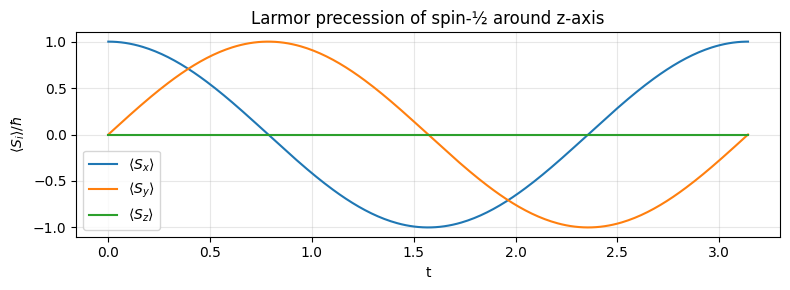

In [16]:
# Spin-1/2: Bloch sphere representation and Larmor precession
sx = np.array([[0,1],[1,0]], complex)
sy = np.array([[0,-1j],[1j,0]], complex)
sz = np.array([[1,0],[0,-1]], complex)
I2 = np.eye(2, dtype=complex)

# Verify Pauli algebra: {si,sj} = 2 delta_ij I
print("Pauli anti-commutators {si,sj}:")
for name_i, Si in [('x',sx),('y',sy),('z',sz)]:
    for name_j, Sj in [('x',sx),('y',sy),('z',sz)]:
        ac = Si@Sj + Sj@Si
        expected = 2*I2 if name_i==name_j else np.zeros((2,2))
        err = np.max(np.abs(ac - expected))
        print(f"  {{s{name_i},s{name_j}}} err={err:.1e}", end="")
    print()

# Larmor precession: |+x> in B field along z
hbar = 1.0  # natural units
omega_L = 2.0   # arbitrary frequency
t_arr = np.linspace(0, 2*np.pi/omega_L, 300)

chi0 = np.array([1, 1], complex)/np.sqrt(2)   # |+x>

Sx_t, Sy_t, Sz_t = [], [], []
for t in t_arr:
    U = np.cos(omega_L*t/2)*I2 - 1j*np.sin(omega_L*t/2)*sz
    chi_t = U @ chi0
    Sx_t.append(np.real(chi_t.conj() @ sx @ chi_t))
    Sy_t.append(np.real(chi_t.conj() @ sy @ chi_t))
    Sz_t.append(np.real(chi_t.conj() @ sz @ chi_t))

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(t_arr, Sx_t, label=r'$\langle S_x\rangle$')
ax.plot(t_arr, Sy_t, label=r'$\langle S_y\rangle$')
ax.plot(t_arr, Sz_t, label=r'$\langle S_z\rangle$')
ax.set_xlabel('t'); ax.set_ylabel(r'$\langle S_i\rangle/\hbar$')
ax.set_title('Larmor precession of spin-½ around z-axis'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## §16  Addition of angular momenta — Clebsch-Gordan coefficients

Combining two spins $j_1$, $j_2$:
$$|j_1,m_1\rangle\otimes|j_2,m_2\rangle = \sum_{J=|j_1-j_2|}^{j_1+j_2}
  \sum_M C_{m_1 m_2}^{J M}\,|J,M\rangle.$$

For two spin-½ particles ($j_1=j_2=\tfrac{1}{2}$):

| Triplet ($J=1$) | Singlet ($J=0$) |
|---|---|
| $|1,1\rangle = |{+}{+}\rangle$ | $|0,0\rangle = \frac{1}{\sqrt{2}}(|{+}{-}\rangle - |{-}{+}\rangle)$ |
| $|1,0\rangle = \frac{1}{\sqrt{2}}(|{+}{-}\rangle + |{-}{+}\rangle)$ | |
| $|1,-1\rangle = |{-}{-}\rangle$ | |

The singlet is a **maximally entangled** (Bell) state.


In [17]:
# Build the two-spin Hilbert space and find J eigenstates
# Basis: |++>, |+->, |-+>, |-->  (m_total = 1, 0, 0, -1)
# Total Sz = Sz1 (x) I2 + I2 (x) Sz2

sx = np.array([[0,1],[1,0]], complex)
sy = np.array([[0,-1j],[1j,0]], complex)
sz = np.array([[1,0],[0,-1]], complex)
I2 = np.eye(2, dtype=complex)

Sz_tot = np.kron(sz, I2) + np.kron(I2, sz)
Sx_tot = np.kron(sx, I2) + np.kron(I2, sx)
Sy_tot = np.kron(sy, I2) + np.kron(I2, sy)
S2_tot = Sx_tot@Sx_tot + Sy_tot@Sy_tot + Sz_tot@Sz_tot

# Diagonalise S^2 to find J eigenvalues
vals, vecs = np.linalg.eigh(S2_tot)
# S^2 eigenvalues = J(J+1): J=0 -> 0, J=1 -> 2 (in units of hbar=1)
print("S² eigenvalues (x4, units hbar=1/2):")
print(np.round(vals, 4))
print("Corresponding J: J=0 gives 0, J=1 gives 2")

# Show the singlet state
singlet_idx = np.argmin(np.abs(vals))
singlet = vecs[:, singlet_idx]
basis = ['|++>','|+->','|-+>','|-->']
print("\nSinglet |0,0> in product basis:")
for b, c in zip(basis, singlet):
    if abs(c) > 0.01:
        print(f"  {c:+.4f}  {b}")


S² eigenvalues (x4, units hbar=1/2):
[0. 8. 8. 8.]
Corresponding J: J=0 gives 0, J=1 gives 2

Singlet |0,0> in product basis:
  -0.7071+0.0000j  |+->
  +0.7071+0.0000j  |-+>


---
## §17  The hydrogen atom

3-D Schrödinger equation in spherical coordinates:
$$-\frac{\hbar^2}{2m}\nabla^2\psi + V(r)\psi = E\psi, \qquad V(r) = -\frac{e^2}{4\pi\epsilon_0 r}.$$

Separation: $\psi_{n\ell m}(r,\theta,\phi) = R_{n\ell}(r)\,Y_\ell^m(\theta,\phi)$.

**Energy levels:**
$$E_n = -\frac{13.6\text{ eV}}{n^2}, \quad n=1,2,3,\ldots$$

**Radial wavefunctions** $R_{n\ell}$: Laguerre polynomials $\times\, e^{-r/na_0}$, $a_0=0.0529$ nm.


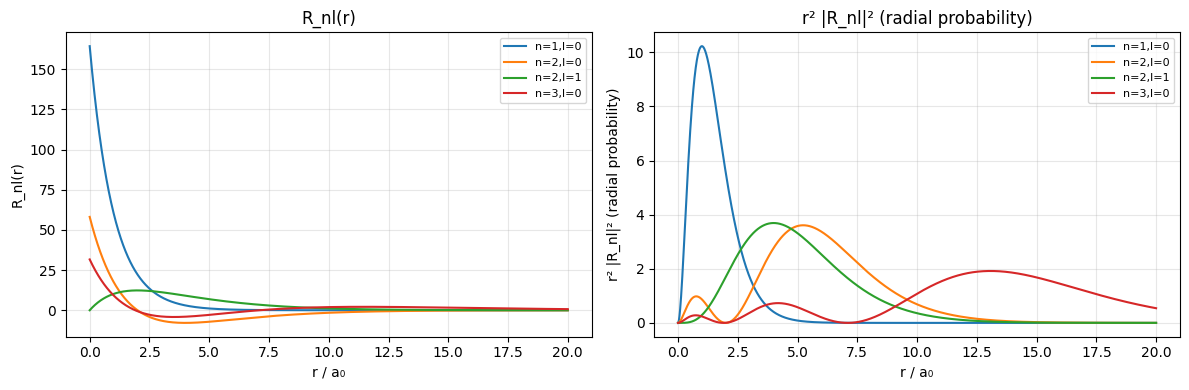

Hydrogen energy levels:
  n=1: E=-13.6000 eV
  n=2: E=-3.4000 eV
  n=3: E=-1.5111 eV
  n=4: E=-0.8500 eV
  n=5: E=-0.5440 eV
  Lyman alpha (n=2->1): 10.200 eV  = 2 PHz


In [18]:
import sympy as sp

r, a0_sym, n_sym = sp.symbols('r a0 n', positive=True)

# First few radial wavefunctions (sympy)
a0 = 0.0529177   # nm (Bohr radius)

R = {
    (1,0): lambda r: 2*(1/a0)**1.5 * np.exp(-r/a0),
    (2,0): lambda r: (1/(2*np.sqrt(2)))*(1/a0)**1.5*(2 - r/a0)*np.exp(-r/(2*a0)),
    (2,1): lambda r: (1/(2*np.sqrt(6)))*(1/a0)**1.5*(r/a0)*np.exp(-r/(2*a0)),
    (3,0): lambda r: (2/(81*np.sqrt(3)))*(1/a0)**1.5*(27-18*r/a0+2*(r/a0)**2)*np.exp(-r/(3*a0)),
}

r_arr = np.linspace(0, 20*a0, 2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (n,l), Rfn in R.items():
    Rnl = Rfn(r_arr)
    prob = r_arr**2 * Rnl**2
    axes[0].plot(r_arr/a0, Rnl, label=f'n={n},l={l}')
    axes[1].plot(r_arr/a0, prob, label=f'n={n},l={l}')

for ax, title in zip(axes, ['R_nl(r)', 'r² |R_nl|² (radial probability)']):
    ax.set_xlabel('r / a₀'); ax.set_ylabel(title)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Energy levels
E_n = lambda n: -13.6 / n**2
print("Hydrogen energy levels:")
for n in range(1, 6):
    print(f"  n={n}: E={E_n(n):.4f} eV")
print(f"  Lyman alpha (n=2->1): {E_n(2)-E_n(1):.3f} eV  = {(E_n(2)-E_n(1))/4.136e-15/1e15:.0f} PHz")


---
## §18  Degeneracy, selection rules, and spectroscopic notation

Each level $n$ has degeneracy $n^2$ (ignoring spin), $2n^2$ with spin:

$$\ell = 0,1,\ldots,n-1 \quad(\text{s,p,d,f,\ldots}),\qquad m = -\ell,\ldots,\ell.$$

**Electric dipole selection rules** (from $[\hat{H}, \hat{L}^2]$ and parity):
$$\Delta\ell = \pm 1, \qquad \Delta m = 0,\pm 1.$$

Spectroscopic series:
| Series | Transition | Range |
|---|---|---|
| Lyman | $n\to 1$ | UV |
| Balmer | $n\to 2$ | visible |
| Paschen | $n\to 3$ | IR |


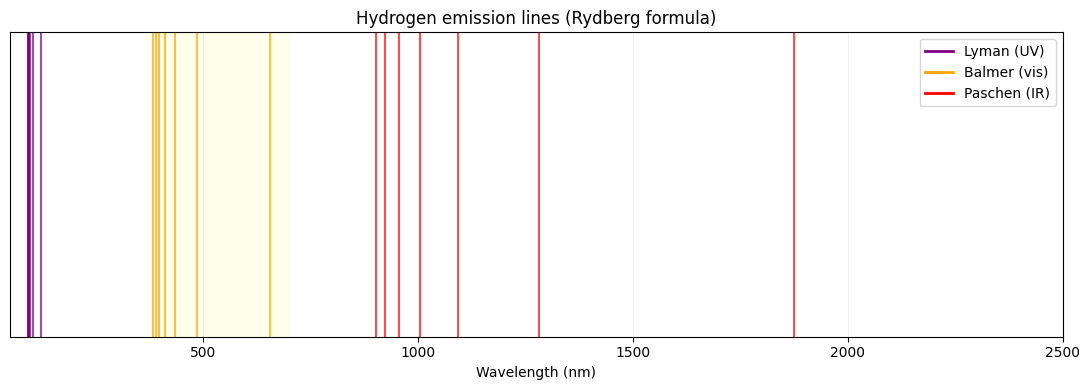

In [19]:
# Hydrogen emission spectrum (Rydberg formula)
R_inf = 13.6   # eV
hc_eV_nm = 1239.84   # eV·nm

fig, ax = plt.subplots(figsize=(11, 4))
series = {'Lyman (UV)': (1,'purple'), 'Balmer (vis)': (2,'orange'),
          'Paschen (IR)': (3,'red')}

for (name, (n_final, color)) in series.items():
    for n_init in range(n_final+1, n_final+8):
        dE = R_inf*(1/n_final**2 - 1/n_init**2)
        lam = hc_eV_nm / dE   # nm
        ax.axvline(lam, color=color, alpha=0.7, lw=1.5)

# wavelength axis label
ax.set_xlabel('Wavelength (nm)')
ax.set_title('Hydrogen emission lines (Rydberg formula)')
ax.set_xlim(50, 2500)
ax.set_yticks([])

for (name,(n_final,color)) in series.items():
    ax.plot([],[], color=color, lw=2, label=name)
ax.legend(); ax.grid(alpha=0.2)
# shade visible range
ax.axvspan(380, 700, alpha=0.08, color='yellow', label='visible')
plt.tight_layout(); plt.show()


---
## §19  Time-independent perturbation theory

$\hat{H} = \hat{H}^{(0)} + \lambda\hat{H}'$.  Expand in $\lambda$:

**Non-degenerate:**
$$E_n^{(1)} = \langle n^{(0)}|\hat{H}'|n^{(0)}\rangle$$
$$E_n^{(2)} = \sum_{m\ne n}\frac{|\langle m^{(0)}|\hat{H}'|n^{(0)}\rangle|^2}{E_n^{(0)}-E_m^{(0)}}$$

**Degenerate:** diagonalise $\hat{H}'$ within the degenerate subspace.

**Fine structure of hydrogen** combines relativistic KE correction + spin-orbit:
$$\Delta E_{\text{fs}} = -\frac{13.6\text{ eV}\,\alpha^2}{n^4}\left(\frac{n}{j+\frac{1}{2}}-\frac{3}{4}\right), \quad \alpha\approx \frac{1}{137}.$$


In [20]:
# First-order perturbation theory: anharmonic oscillator V' = lambda*x^4
# Compare with exact numerical diagonalisation
x_nm = np.linspace(-20, 20, 1500)
dx = x_nm[1] - x_nm[0]
omega0 = 0.005   # eV/nm^2

# Unperturbed harmonic
E0, phi0 = solve(lambda x: harmonic(x, omega0), x_nm, n_states=6)

# First-order correction: <n|lambda*x^4|n>
lam = 1e-5   # eV/nm^4  (weak perturbation)
E1_correction = np.array([lam * np.sum(phi0[n]**2 * x_nm**4) * dx for n in range(6)])

# Exact (perturbed)
E_exact, _ = solve(lambda x: harmonic(x, omega0) + lam*x**4, x_nm, n_states=6)

print(f"{'n':>3}  {'E0 (eV)':>12}  {'E0+E1 (eV)':>12}  {'Exact (eV)':>12}  {'1st-order err':>14}")
for n in range(6):
    print(f"{n:>3}  {E0[n]:>12.6f}  {E0[n]+E1_correction[n]:>12.6f}"
          f"  {E_exact[n]:>12.6f}  {abs(E0[n]+E1_correction[n]-E_exact[n]):>14.2e}")


  n       E0 (eV)    E0+E1 (eV)    Exact (eV)   1st-order err
  0      0.013802      0.013859      0.013859        5.40e-07
  1      0.041405      0.041691      0.041687        4.20e-06
  2      0.069008      0.069751      0.069735        1.55e-05
  3      0.096609      0.098038      0.097999        3.92e-05
  4      0.124210      0.126553      0.126473        7.97e-05
  5      0.151810      0.155295      0.155154        1.42e-04


---
## §20  Variational principle

$$E_\text{gs} \leq \frac{\langle\psi_\text{trial}|\hat{H}|\psi_\text{trial}\rangle}{\langle\psi_\text{trial}|\psi_\text{trial}\rangle}$$

Choose a parameterised trial state, minimise over parameters → upper bound on ground state.

**Example:** Gaussian trial for the harmonic oscillator.
$\psi_b(x) = (b/\pi)^{1/4}e^{-bx^2/2}$ → $\langle H\rangle = \hbar\omega(b/\omega+\omega/b)/4$ minimised at $b=\omega$, recovering exact $E_0$.


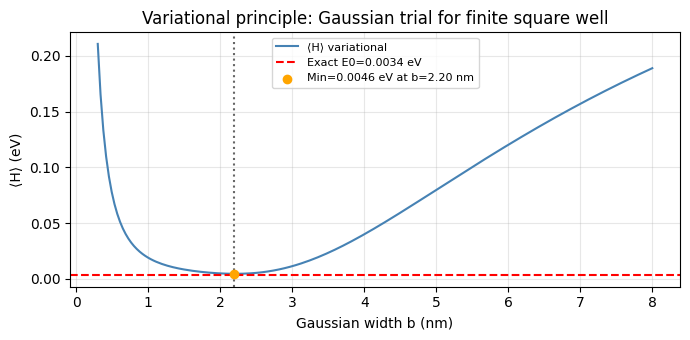

Variational bound: 0.00461 eV  |  Exact: 0.00339 eV
Variational is above exact (as required)


In [21]:
# Variational principle: Gaussian trial for the finite square well
L, V0 = 10.0, 0.5   # nm, eV
x_nm = np.linspace(-20, 20, 1500)
dx = x_nm[1] - x_nm[0]
V = finite_square_well(x_nm, L, V0)

# Exact ground state
E_exact, _ = solve(lambda x: finite_square_well(x, L, V0), x_nm, n_states=1)

# Variational: Gaussian with width b
b_vals = np.linspace(0.3, 8, 200)
E_var = []
for b in b_vals:
    psi = np.exp(-x_nm**2 / (2*b**2))
    psi /= np.sqrt(np.sum(psi**2)*dx)
    d2psi = np.gradient(np.gradient(psi, dx), dx)
    T = -HBAR2_OVER_2M * np.sum(psi * d2psi) * dx
    Vexp = np.sum(psi**2 * V) * dx
    E_var.append(T + Vexp)

b_opt = b_vals[np.argmin(E_var)]
E_var_min = min(E_var)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(b_vals, E_var, color='steelblue', label='⟨H⟩ variational')
ax.axhline(E_exact[0], color='red', ls='--', label=f'Exact E0={E_exact[0]:.4f} eV')
ax.axvline(b_opt, color='k', ls=':', alpha=0.6)
ax.scatter([b_opt], [E_var_min], color='orange', zorder=5,
           label=f'Min={E_var_min:.4f} eV at b={b_opt:.2f} nm')
ax.set_xlabel('Gaussian width b (nm)'); ax.set_ylabel('⟨H⟩ (eV)')
ax.set_title('Variational principle: Gaussian trial for finite square well')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"Variational bound: {E_var_min:.5f} eV  |  Exact: {E_exact[0]:.5f} eV")
print(f"Variational is {'above' if E_var_min >= E_exact[0]-1e-6 else 'BELOW — bug!'} exact (as required)")


---
## §21  Identical particles

**Spin-statistics theorem:** indistinguishable particles must have a
wavefunction that is antisymmetric (fermions, half-integer spin) or
symmetric (bosons, integer spin) under exchange of any two particles.

**Two-particle state:**
$$\Psi_\pm(x_1,x_2) = \frac{1}{\sqrt{2}}\bigl[\psi_a(x_1)\psi_b(x_2)\pm\psi_a(x_2)\psi_b(x_1)\bigr].$$

**Fermi-Dirac** (−): $\Psi_- = 0$ when $a=b$ → **Pauli exclusion principle**.

**Exchange force**: even without interaction,
$\langle(x_1-x_2)^2\rangle$ differs for ±.


In [22]:
# Exchange force: <(x1-x2)^2> for distinguishable, bosons, fermions
x = np.linspace(-15, 15, 1000)
dx = x[1] - x[0]

# Use first two box eigenstates
psi_a = psi_box(1, x + 7.5, 15.0)   # shifted to [-7.5,7.5]
psi_b = psi_box(2, x + 7.5, 15.0)

# normalise
psi_a /= np.sqrt(np.sum(psi_a**2)*dx)
psi_b /= np.sqrt(np.sum(psi_b**2)*dx)

xx1, xx2 = np.meshgrid(x, x)
pa1 = np.outer(psi_a, np.ones(len(x)))   # psi_a(x1)
pa2 = np.outer(np.ones(len(x)), psi_a)   # psi_a(x2)
pb1 = np.outer(psi_b, np.ones(len(x)))
pb2 = np.outer(np.ones(len(x)), psi_b)

Psi_dist = pa1 * pb2                      # distinguishable
Psi_bos  = (pa1*pb2 + pa2*pb1)/np.sqrt(2)
Psi_fer  = (pa1*pb2 - pa2*pb1)/np.sqrt(2)

sep2 = (xx1 - xx2)**2

def expect_sep(Psi):
    norm = np.sum(np.abs(Psi)**2) * dx**2
    return np.sum(np.abs(Psi)**2 * sep2) * dx**2 / norm

print("Mean square separation <(x1-x2)²> (nm²):")
print(f"  Distinguishable: {expect_sep(Psi_dist):.4f}")
print(f"  Bosons    (+):   {expect_sep(Psi_bos):.4f}  (closer — bunching)")
print(f"  Fermions  (-):   {expect_sep(Psi_fer):.4f}  (farther — antibunching)")


Mean square separation <(x1-x2)²> (nm²):
  Distinguishable: 158.8262
  Bosons    (+):   77.9328  (closer — bunching)
  Fermions  (-):   239.7196  (farther — antibunching)


---
## §22  THz connection — intersubband transitions

The transition frequency between bound states is
$$f_{01} = \frac{E_1 - E_0}{h}.$$

For GaAs-like wells ($L\sim 10$ nm, $V_0\sim 0.3$ eV) this falls in the
**THz window (0.3–10 THz)** — the operating range of quantum cascade lasers (QCL)
and the dispersion-assisted GS system in this repo.

The next two sections sweep well depth and width, watching how $f_{01}$ tracks
across the THz band.


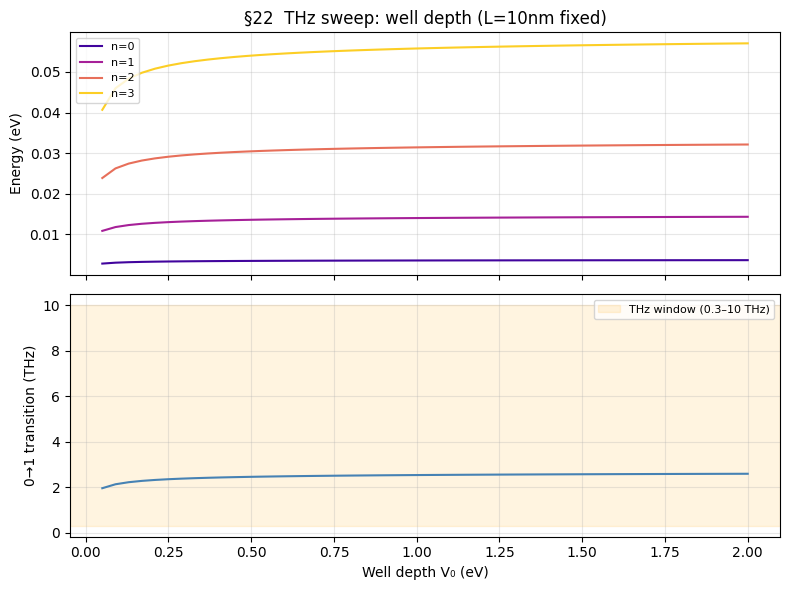

In [23]:
# Sweep well depth: V0 from 0.05 to 2.0 eV, L=10nm
result_d = sweep_depth(L_nm=10.0, V0_range=(0.05, 2.0), n_V=50, n_states=4)
fig = plot_sweep(result_d, title='§22  THz sweep: well depth (L=10nm fixed)')
plt.show()


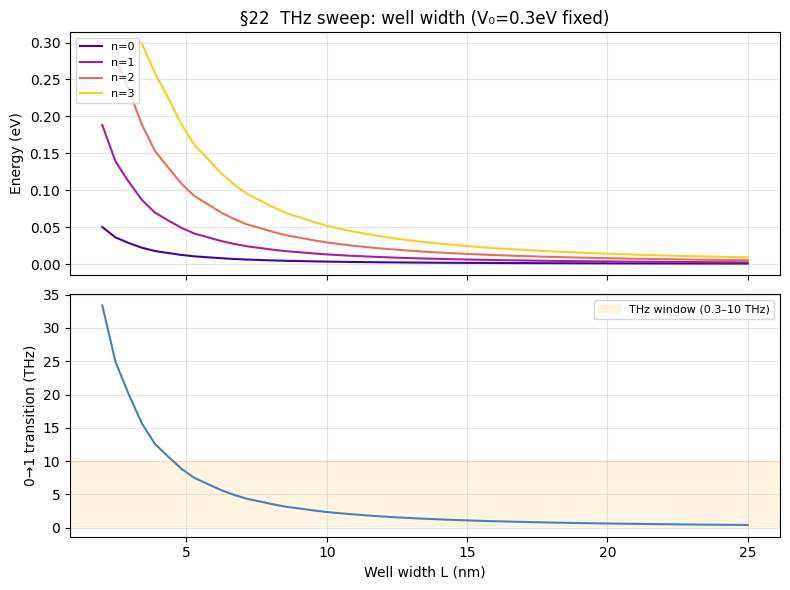

In [24]:
# Sweep well width: L from 2 to 25 nm, V0=0.3eV (GaAs-like)
result_w = sweep_width(V0_eV=0.3, L_range=(2.0, 25.0), n_L=50, n_states=4)
fig = plot_sweep(result_w, title='§22  THz sweep: well width (V₀=0.3eV fixed)')
plt.show()


In [25]:
# Print the THz window summary
d = result_d
in_thz = (d['thz_01'] > 0.3) & (d['thz_01'] < 10.0)
V0s = d['param']
print("V0 range for THz 0→1 transition (0.3–10 THz), L=10nm:")
if np.any(in_thz):
    print(f"  V0 = [{V0s[in_thz][0]:.3f}, {V0s[in_thz][-1]:.3f}] eV")
    print(f"  f range = [{d['thz_01'][in_thz].min():.2f}, {d['thz_01'][in_thz].max():.2f}] THz")

w = result_w
in_thz_w = (w['thz_01'] > 0.3) & (w['thz_01'] < 10.0)
Ls = w['param']
print("\nL range for THz transition, V0=0.3eV:")
if np.any(in_thz_w):
    print(f"  L = [{Ls[in_thz_w][0]:.1f}, {Ls[in_thz_w][-1]:.1f}] nm")


V0 range for THz 0→1 transition (0.3–10 THz), L=10nm:
  V0 = [0.050, 2.000] eV
  f range = [1.95, 2.59] THz

L range for THz transition, V0=0.3eV:
  L = [4.8, 25.0] nm


---
## §23  Year-1 summary and connections

| Topic | Key formula | Engineering connection |
|---|---|---|
| Hilbert space | $\langle f|g\rangle = \int f^*g\,dx$ | Inner product = correlation integral |
| Dirac notation | $\hat{I} = \sum_n|n\rangle\langle n|$ | Completeness = basis decomposition |
| TISE | $\hat{H}\psi = E\psi$ | Eigenvalue problem → `np.linalg.eigh` |
| HUP | $\sigma_x\sigma_p \geq \hbar/2$ | Time-bandwidth product in pulses |
| Ladder ops | $[\hat{a},\hat{a}^\dagger]=1$ | Boson creation/annihilation in photonics |
| Angular momentum | $[L_i,L_j]=i\hbar\epsilon_{ijk}L_k$ | Rotation group → SO(3) → ML symmetry |
| Hydrogen | $E_n=-13.6/n^2$ eV | Spectroscopy → remote sensing |
| Perturbation | $E_n^{(1)} = \langle n|H'|n\rangle$ | Linear response, fine structure |
| Identical particles | $\Psi_- = 0$ when $a=b$ | Pauli exclusion → solid state |
| THz QW | $f_{01}=\Delta E/h$ | QCL operating frequency design |

**Griffiths → ML axis:**

- Hermitian operators with real eigenvalues → PCA / SVD (Hermitian covariance matrix)
- Angular momentum algebra (raising/lowering) → transformer attention heads
- Variational principle $\langle H\rangle$ minimisation → loss function gradient descent
- Green's functions for TISE → Fourier Neural Operators (FNO) in `dgs.gs_fno`
